In [67]:
ls

all_data_100ms_1core.csv             all_data_50ms_apiserver_pinned.csv
all_data_100ms_apiserver.csv         all_data_50ms.csv
all_data_100ms_apiserver_pinned.csv  all_data_50ms_hybrid.csv
all_data_100ms.csv                   alldata_ecdf_overlay.pdf
all_data_100ms_hybrid.csv            alldata_ecdf_overlay.png
all_data_10ms_1core.csv              allfinal_ecdf_overlay.pdf
all_data_10ms_apiserver.csv          allfinal_ecdf_overlay.png
all_data_10ms_apiserver_pinned.csv   func_ecdf_overlay.pdf
all_data_10ms.csv                    func_ecdf_overlay.png
all_data_10ms_hybrid.csv             overhead_abs.pdf
all_data_1s_1core.csv                overhead_abs.png
all_data_1s_apiserver_pinned.csv     overhead_barplot_percentiles.pdf
all_data_1s.csv                      overhead_barplot_percentiles.png
all_data_1s_hybrid.csv               overhead_ecdf_overlay.pdf
all_data_200ms_1core.csv             overhead_ecdf_overlay.png
all_data_200ms_apiserver.csv         overhead_relative.pdf
all_data_2

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Delays with data: ['10ms', '50ms', '100ms', '200ms', '1s']
  [OK]   Local / 10ms — 20000 samples, median=5883.4ms, p99=25343.1ms
  [OK]   Hybrid / 10ms — 20000 samples, median=3923.8ms, p99=24168.5ms
  [OK]   Local 1core / 10ms — 20000 samples, median=5799.6ms, p99=25449.1ms
  [OK]   Local / 50ms — 20010 samples, median=90.7ms, p99=7851.8ms
  [OK]   Hybrid / 50ms — 20010 samples, median=97.5ms, p99=6812.1ms
  [OK]   Local 1core / 50ms — 20010 samples, median=87.6ms, p99=7547.5ms
  [OK]   Local / 100ms — 20010 samples, median=82.2ms, p99=6482.3ms
  [OK]   Hybrid / 100ms — 20010 samples, median=93.1ms, p99=6762.1ms
  [OK]   Local 1core / 100ms — 20010 samples, median=85.5ms, p99=5713.2ms
  [OK]   Local / 200ms — 20010 samples, median=79.9ms, p99=5500.5ms
  [OK]   Hybrid / 200ms — 20010 samples, median=86.7ms, p99=5789.9ms
  [OK]   Local 1core / 200ms — 20010 samples, median=89.4ms, p99=5387.3ms
  [OK]   Local / 1s — 20000 samples, median=68.9ms, p99=2874.5ms
  [OK]   Hybrid / 1s — 20000 

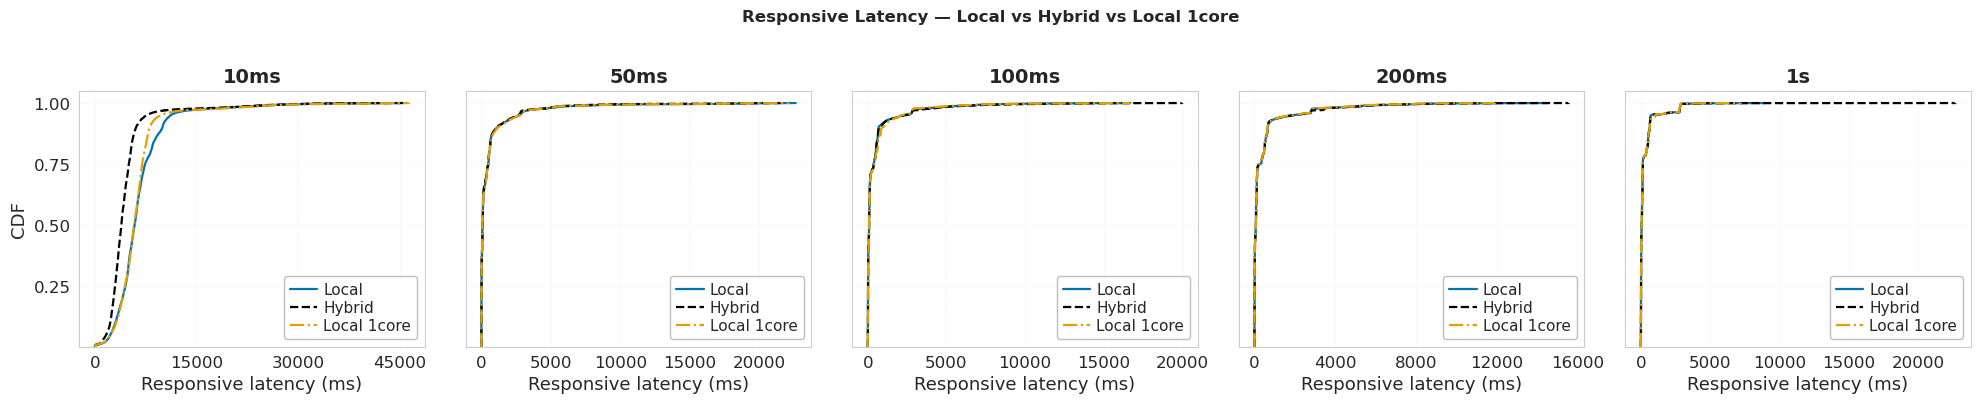

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import os

# ─── STYLE ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          13,
    "axes.titlesize":     14,
    "axes.labelsize":     13,
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "legend.fontsize":    11,
    "legend.framealpha":  0.85,
    "legend.edgecolor":   "0.7",
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "grid.linewidth":     0.4,
    "grid.alpha":         0.4,
    "grid.color":         "0.75",
    "lines.linewidth":    1.6,
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

sns.set_style("whitegrid")

# ─── PALETTE ──────────────────────────────────────────────────────────
COLORS     = ["#0072B2", "#000000",  "#E69F00"]   # noir, bleu, orange
LINESTYLES = ["-",       "--",      "-."]
LABELS     = ["Local", "Hybrid", "Local 1core"]

# ─── CONFIG ───────────────────────────────────────────────────────────
DELAYS = ["10ms", "50ms", "100ms", "200ms", "1s"]

DATA_DIR = "."

FILES = {
    "Local": {
        d: os.path.join(DATA_DIR, f"all_data_{d}.csv") for d in DELAYS
    },
    "Hybrid": {
        d: os.path.join(DATA_DIR, f"all_data_{d}_hybrid.csv") for d in DELAYS
    },
    "Local 1core": {
        d: os.path.join(DATA_DIR, f"all_data_{d}_1core.csv") for d in DELAYS
    },
}

MODES = ["Local", "Hybrid", "Local 1core"]

# ─── CHARGEMENT ───────────────────────────────────────────────────────
def load_series(filepath):
    if filepath is None or not os.path.exists(filepath):
        return None
    df = pd.read_csv(filepath)
    return df["latency_ms"].dropna()

# ─── STYLE AXES ───────────────────────────────────────────────────────
def style_ax(ax):
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
    ax.tick_params(direction='out', length=3, width=0.6, pad=3)
    ax.grid(True, linestyle=':', linewidth=0.4, color='0.75')

# ─── CHECK AVAILABLE FILES ────────────────────────────────────────────
available_delays = []
for d in DELAYS:
    has_any = any(os.path.exists(FILES[m][d]) for m in MODES)
    if has_any:
        available_delays.append(d)

print(f"Delays with data: {available_delays}")
if not available_delays:
    raise RuntimeError("Aucun fichier trouvé — vérifiez DATA_DIR et les noms de fichiers.")

# ─── FIGURE ───────────────────────────────────────────────────────────
n = len(available_delays)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

for c, delay in enumerate(available_delays):
    ax = axes[c]

    for i, mode in enumerate(MODES):
        filepath = FILES[mode][delay]
        data = load_series(filepath)
        if data is None:
            print(f"  [SKIP] {mode} / {delay} — file not found")
            continue

        print(f"  [OK]   {mode} / {delay} — {len(data)} samples, median={data.median():.1f}ms, p99={data.quantile(0.99):.1f}ms")

        sns.ecdfplot(
            data=data,
            ax=ax,
            color=COLORS[i],
            linestyle=LINESTYLES[i],
            linewidth=1.6,
            label=LABELS[i],
        )

    ax.set_title(delay, fontweight='bold')
    ax.set_xlabel("Responsive latency (ms)")

    if c == 0:
        ax.set_ylabel("CDF")

    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:.2f}"))

    ax.legend(
        loc='lower right',
        handlelength=1.8,
        borderpad=0.4,
        labelspacing=0.2,
        handletextpad=0.4,
    )

    style_ax(ax)

# ─── TITRE ────────────────────────────────────────────────────────────
fig.suptitle(
    "Responsive Latency — Local vs Hybrid vs Local 1core",
    fontsize=12,
    fontweight='bold',
    y=1.01,
)

plt.tight_layout()

# ─── EXPORT ───────────────────────────────────────────────────────────
out_pdf = "resp_ecdf_overlay.pdf"
out_png = "resp_ecdf_overlay.png"

plt.savefig(out_pdf, dpi=300, bbox_inches="tight")
plt.savefig(out_png, dpi=300, bbox_inches="tight")

print(f"\n✓ Saved: {out_pdf}")
print(f"✓ Saved: {out_png}")

In [62]:
import os
import pandas as pd

DELAYS = ["10ms", "50ms", "100ms", "200ms", "1s"]
DATA_DIR = "."

FILES = {
    "Local":          {d: os.path.join(DATA_DIR, f"all_data_{d}.csv")                  for d in DELAYS},
    "Hybrid":         {d: os.path.join(DATA_DIR, f"all_data_{d}_hybrid.csv")           for d in DELAYS},
    "Local1core":     {d: os.path.join(DATA_DIR, f"all_data_{d}_1core.csv")            for d in DELAYS},
    "APIserver":      {d: os.path.join(DATA_DIR, f"all_data_{d}_apiserver.csv")        for d in DELAYS},
    "APIserverPinned":{d: os.path.join(DATA_DIR, f"all_data_{d}_apiserver_pinned.csv") for d in DELAYS},
}
 


for mode, files in FILES.items():
    for delay, path in files.items():
        if not os.path.exists(path):
            print(f"Missing file: {path}")
            continue
        df = pd.read_csv(path)
        df["diff"] = df["latency_ms"] - df["execution_time_sec"]
        df.to_csv(path, index=False)
        print(f"Updated: {path}")

Updated: ./all_data_10ms.csv
Updated: ./all_data_50ms.csv
Updated: ./all_data_100ms.csv
Updated: ./all_data_200ms.csv
Updated: ./all_data_1s.csv
Updated: ./all_data_10ms_hybrid.csv
Updated: ./all_data_50ms_hybrid.csv
Updated: ./all_data_100ms_hybrid.csv
Updated: ./all_data_200ms_hybrid.csv
Updated: ./all_data_1s_hybrid.csv
Updated: ./all_data_10ms_1core.csv
Updated: ./all_data_50ms_1core.csv
Updated: ./all_data_100ms_1core.csv
Updated: ./all_data_200ms_1core.csv
Updated: ./all_data_1s_1core.csv
Updated: ./all_data_10ms_apiserver.csv
Updated: ./all_data_50ms_apiserver.csv
Updated: ./all_data_100ms_apiserver.csv
Updated: ./all_data_200ms_apiserver.csv
Missing file: ./all_data_1s_apiserver.csv
Updated: ./all_data_10ms_apiserver_pinned.csv
Updated: ./all_data_50ms_apiserver_pinned.csv
Updated: ./all_data_100ms_apiserver_pinned.csv
Updated: ./all_data_200ms_apiserver_pinned.csv
Updated: ./all_data_1s_apiserver_pinned.csv


Delays with data: ['10ms', '50ms', '100ms', '200ms', '1s']
  [OK] Local / 10ms — median=5883.4ms, p99=25343.1ms
  [OK] Hybrid / 10ms — median=3923.8ms, p99=24168.5ms
  [OK] Local 1core / 10ms — median=5799.6ms, p99=25449.1ms
  [OK] Local APIserver / 10ms — median=5573.1ms, p99=25195.1ms
  [OK] Local / 50ms — median=90.7ms, p99=7851.8ms
  [OK] Hybrid / 50ms — median=97.5ms, p99=6812.1ms
  [OK] Local 1core / 50ms — median=87.6ms, p99=7547.5ms
  [OK] Local APIserver / 50ms — median=88.7ms, p99=8203.1ms
  [OK] Local / 100ms — median=82.2ms, p99=6482.3ms
  [OK] Hybrid / 100ms — median=93.1ms, p99=6762.1ms
  [OK] Local 1core / 100ms — median=85.5ms, p99=5713.2ms
  [OK] Local APIserver / 100ms — median=86.2ms, p99=5406.5ms
  [OK] Local / 200ms — median=79.9ms, p99=5500.5ms
  [OK] Hybrid / 200ms — median=86.7ms, p99=5789.9ms
  [OK] Local 1core / 200ms — median=89.4ms, p99=5387.3ms
  [OK] Local APIserver / 200ms — median=86.9ms, p99=5446.6ms
  [OK] Local / 1s — median=68.9ms, p99=2874.5ms
  [OK

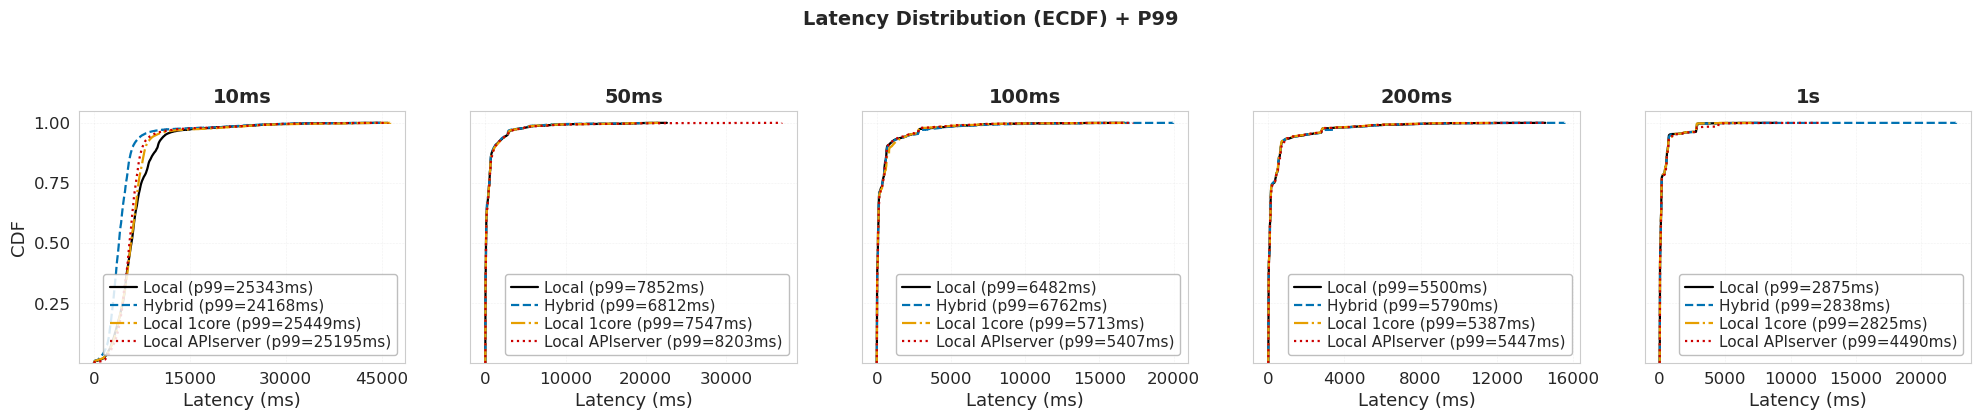

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import os

# ─── STYLE ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          13,
    "axes.titlesize":     14,
    "axes.labelsize":     13,
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "legend.fontsize":    11,
    "legend.framealpha":  0.85,
    "legend.edgecolor":   "0.7",
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "grid.linewidth":     0.4,
    "grid.alpha":         0.4,
    "grid.color":         "0.75",
    "lines.linewidth":    1.6,
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

sns.set_style("whitegrid")

# ─── PALETTE ──────────────────────────────────────────────────────────
COLORS = ["#000000", "#0072B2", "#E69F00", "#CC0000"]
LINESTYLES = ["-", "--", "-.", ":"]
LABELS = ["Local", "Hybrid", "Local 1core", "Local APIserver"]

# ─── CONFIG ───────────────────────────────────────────────────────────
DELAYS = ["10ms", "50ms", "100ms", "200ms", "1s"]

DATA_DIR = "."

FILES = {
    "Local": {
        d: os.path.join(DATA_DIR, f"all_data_{d}.csv") for d in DELAYS
    },
    "Hybrid": {
        d: os.path.join(DATA_DIR, f"all_data_{d}_hybrid.csv") for d in DELAYS
    },
    "Local 1core": {
        d: os.path.join(DATA_DIR, f"all_data_{d}_1core.csv") for d in DELAYS
    },
    "Local APIserver": {
        d: os.path.join(DATA_DIR, f"all_data_{d}_apiserver_pinned.csv") for d in DELAYS
    },
}

MODES = ["Local", "Hybrid", "Local 1core", "Local APIserver"]

# ─── LOAD ─────────────────────────────────────────────────────────────
def load_series(filepath):
    if filepath is None or not os.path.exists(filepath):
        return None
    df = pd.read_csv(filepath)
    return df["latency_ms"].dropna()

# ─── STYLE AXES ───────────────────────────────────────────────────────
def style_ax(ax):
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
    ax.tick_params(direction='out', length=3, width=0.6, pad=3)
    ax.grid(True, linestyle=':', linewidth=0.4, color='0.75')

# ─── AVAILABLE DELAYS ─────────────────────────────────────────────────
available_delays = [
    d for d in DELAYS
    if any(os.path.exists(FILES[m][d]) for m in MODES)
]

print(f"Delays with data: {available_delays}")
if not available_delays:
    raise RuntimeError("Aucun fichier trouvé")

# ─── FIGURE ───────────────────────────────────────────────────────────
n = len(available_delays)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

for c, delay in enumerate(available_delays):
    ax = axes[c]

    for i, mode in enumerate(MODES):
        filepath = FILES[mode][delay]
        data = load_series(filepath)

        if data is None:
            print(f"  [SKIP] {mode} / {delay}")
            continue

        p99 = data.quantile(0.99)

        print(f"  [OK] {LABELS[i]} / {delay} — "
              f"median={data.median():.1f}ms, p99={p99:.1f}ms")

        sns.ecdfplot(
            data=data,
            ax=ax,
            color=COLORS[i],
            linestyle=LINESTYLES[i],
            linewidth=1.6,
            label=f"{LABELS[i]} (p99={p99:.0f}ms)"
        )

    ax.set_title(delay, fontweight='bold')
    ax.set_xlabel("Latency (ms)")

    if c == 0:
        ax.set_ylabel("CDF")

    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:.2f}"))

    ax.legend(
        loc='lower right',
        handlelength=1.8,
        borderpad=0.4,
        labelspacing=0.2,
        handletextpad=0.4,
    )

    style_ax(ax)

# ─── TITLE ────────────────────────────────────────────────────────────
fig.suptitle(
    "Latency Distribution (ECDF) + P99",
    fontsize=14,
    fontweight='bold',
    y=1.05
)

plt.tight_layout()

# ─── EXPORT ───────────────────────────────────────────────────────────
out_pdf = "ecdf_p99_label.pdf"
out_png = "ecdf_p99_label.png"

plt.savefig(out_pdf, dpi=300, bbox_inches="tight")
plt.savefig(out_png, dpi=300, bbox_inches="tight")

print(f"\n✓ Saved: {out_pdf}")
print(f"✓ Saved: {out_png}")

plt.show()

Delays with data: ['10ms', '50ms', '100ms', '200ms', '1s']
  [OK]   Local                          / 10ms — p50=5671.9  p95=10552.3  p99=23311.8
  [OK]   Hybrid                         / 10ms — p50=3753.6  p95=6840.7  p99=22710.5
  [OK]   Local 1core                    / 10ms — p50=5617.8  p95=8838.8  p99=24205.7
  [OK]   Local APIserver                / 10ms — p50=5408.4  p95=8236.0  p99=23419.6
  [OK]   Local                          / 50ms — p50=16.1  p95=1848.5  p99=5854.6
  [OK]   Hybrid                         / 50ms — p50=14.5  p95=1846.7  p99=4932.5
  [OK]   Local 1core                    / 50ms — p50=13.7  p95=1923.7  p99=5354.3
  [OK]   Local APIserver                / 50ms — p50=15.8  p95=1875.6  p99=5640.4
  [OK]   Local                          / 100ms — p50=12.1  p95=1052.0  p99=4447.7
  [OK]   Hybrid                         / 100ms — p50=13.4  p95=1062.6  p99=4893.2
  [OK]   Local 1core                    / 100ms — p50=12.8  p95=1156.6  p99=4104.7
  [OK]   Local APIserve

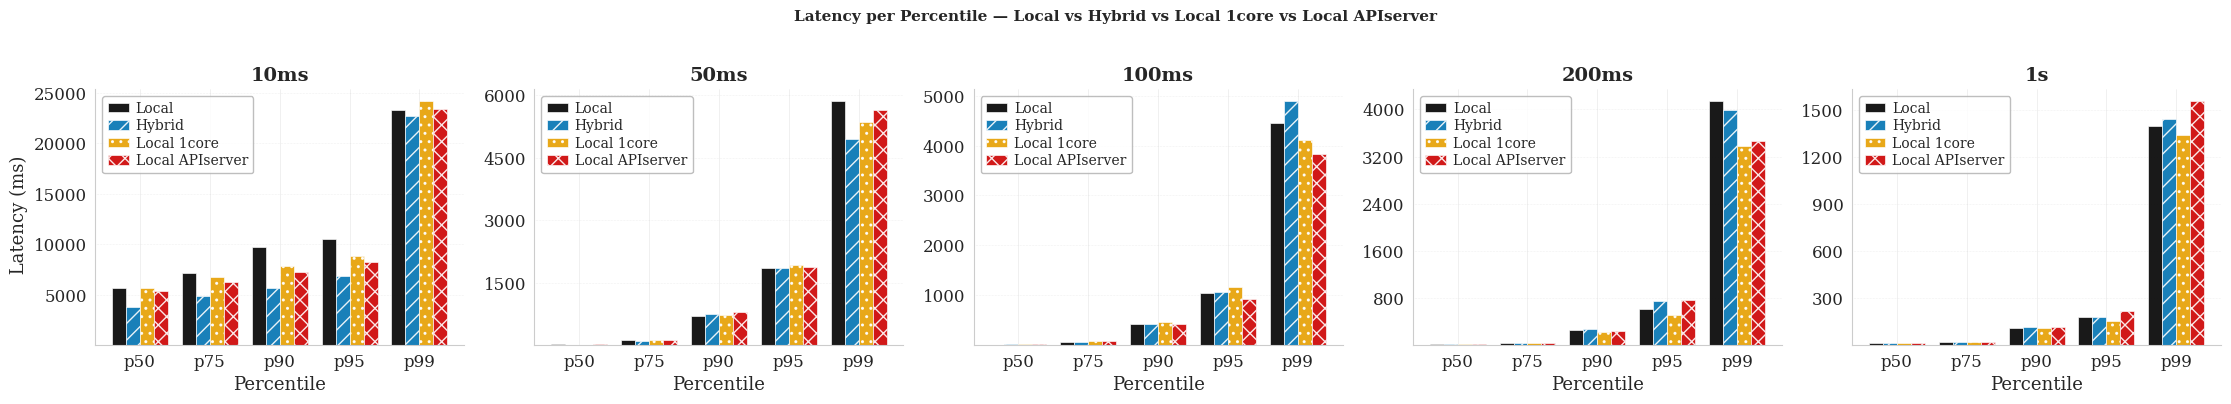

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os

# ─── STYLE ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          13,
    "axes.titlesize":     14,
    "axes.labelsize":     13,
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "legend.fontsize":    10,
    "legend.framealpha":  0.85,
    "legend.edgecolor":   "0.7",
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "grid.linewidth":     0.4,
    "grid.alpha":         0.4,
    "grid.color":         "0.75",
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

# ─── PALETTE ──────────────────────────────────────────────────────────
COLORS = ["#000000", "#0072B2", "#E69F00", "#CC0000"]
LABELS = ["Local", "Hybrid", "Local 1core", "Local APIserver"]
HATCHES = ["", "//", "..", "xx"]

# ─── CONFIG ───────────────────────────────────────────────────────────
DELAYS = ["10ms", "50ms", "100ms", "200ms", "1s"]
PERCENTILES = [50, 75, 90, 95, 99]
PCTILE_LABELS = ["p50", "p75", "p90", "p95", "p99"]

DATA_DIR = "."

FILES = {
    "Local":      {d: os.path.join(DATA_DIR, f"all_data_{d}.csv")           for d in DELAYS},
    "Hybrid":     {d: os.path.join(DATA_DIR, f"all_data_{d}_hybrid.csv")    for d in DELAYS},
    "Local1core": {d: os.path.join(DATA_DIR, f"all_data_{d}_1core.csv")     for d in DELAYS},
    "Local APIserver":  {d: os.path.join(DATA_DIR, f"all_data_{d}_apiserver_pinned.csv") for d in DELAYS},
}

MODES = ["Local", "Hybrid", "Local1core", "Local APIserver"]

# ─── CHARGEMENT ───────────────────────────────────────────────────────
def load_series(filepath):
    if filepath is None or not os.path.exists(filepath):
        return None
    df = pd.read_csv(filepath)
    if "diff" not in df.columns:
        return None
    return df["diff"].dropna()

# ─── CHECK AVAILABLE FILES ────────────────────────────────────────────
available_delays = []
for d in DELAYS:
    has_any = any(os.path.exists(FILES[m][d]) for m in MODES)
    if has_any:
        available_delays.append(d)

print(f"Delays with data: {available_delays}")
if not available_delays:
    raise RuntimeError("Aucun fichier trouvé — vérifiez DATA_DIR et les noms de fichiers.")

# ─── FIGURE ───────────────────────────────────────────────────────────
n = len(available_delays)
fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4), sharey=False)
if n == 1:
    axes = [axes]

n_modes = len(MODES)
n_pctiles = len(PERCENTILES)
x = np.arange(n_pctiles)
bar_width = 0.8 / n_modes  # barres groupées

for c, delay in enumerate(available_delays):
    ax = axes[c]

    for i, mode in enumerate(MODES):
        filepath = FILES[mode][delay]
        data = load_series(filepath)
        if data is None:
            print(f"  [SKIP] {LABELS[i]} / {delay} — file not found")
            continue

        vals = [np.percentile(data, p) for p in PERCENTILES]
        offset = (i - n_modes / 2 + 0.5) * bar_width

        bars = ax.bar(
            x + offset, vals,
            width=bar_width,
            color=COLORS[i],
            hatch=HATCHES[i],
            label=LABELS[i],
            edgecolor="white",
            linewidth=0.5,
            alpha=0.9,
        )

        print(f"  [OK]   {LABELS[i]:30s} / {delay} — "
              f"p50={vals[0]:.1f}  p95={vals[3]:.1f}  p99={vals[4]:.1f}")

    ax.set_title(delay, fontweight='bold')
    ax.set_xlabel("Percentile")
    ax.set_xticks(x)
    ax.set_xticklabels(PCTILE_LABELS)

    if c == 0:
        ax.set_ylabel(" Latency (ms)")

    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, prune='both'))
    ax.grid(True, axis='y', linestyle=':', linewidth=0.4, color='0.75')
    ax.tick_params(direction='out', length=3, width=0.6, pad=3)

    ax.legend(
        loc='upper left',
        handlelength=1.5,
        borderpad=0.4,
        labelspacing=0.25,
        handletextpad=0.5,
    )

# ─── TITRE ────────────────────────────────────────────────────────────
fig.suptitle(
    "Latency per Percentile — Local vs Hybrid vs Local 1core vs Local APIserver",
    fontsize=11,
    fontweight='bold',
    y=1.01,
)

plt.tight_layout()

# ─── EXPORT ───────────────────────────────────────────────────────────
out_pdf = "overhead_barplot_percentiles.pdf"
out_png = "overhead_barplot_percentiles.png"

plt.savefig(out_pdf, dpi=300, bbox_inches="tight")
plt.savefig(out_png, dpi=300, bbox_inches="tight")

print(f"\n✓ Saved: {out_pdf}")
print(f"✓ Saved: {out_png}")

Delays with data: ['10ms', '50ms', '100ms', '200ms', '1s']
  [ABS] Local                               / 10ms p50=5671.9 p99=23311.8
  [ABS] Hybrid                              / 10ms p50=3753.6 p99=22710.5
  [ABS] Local 1core                         / 10ms p50=5617.8 p99=24205.7
  [ABS] Local (API server + pinned)         / 10ms p50=5408.4 p99=23419.6
  [ABS] Local                               / 50ms p50=16.1 p99=5854.6
  [ABS] Hybrid                              / 50ms p50=14.5 p99=4932.5
  [ABS] Local 1core                         / 50ms p50=13.7 p99=5354.3
  [ABS] Local (API server + pinned)         / 50ms p50=15.8 p99=5640.4
  [ABS] Local                               / 100ms p50=12.1 p99=4447.7
  [ABS] Hybrid                              / 100ms p50=13.4 p99=4893.2
  [ABS] Local 1core                         / 100ms p50=12.8 p99=4104.7
  [ABS] Local (API server + pinned)         / 100ms p50=13.1 p99=3828.2
  [ABS] Local                               / 200ms p50=11.9 p99=4143.2
 

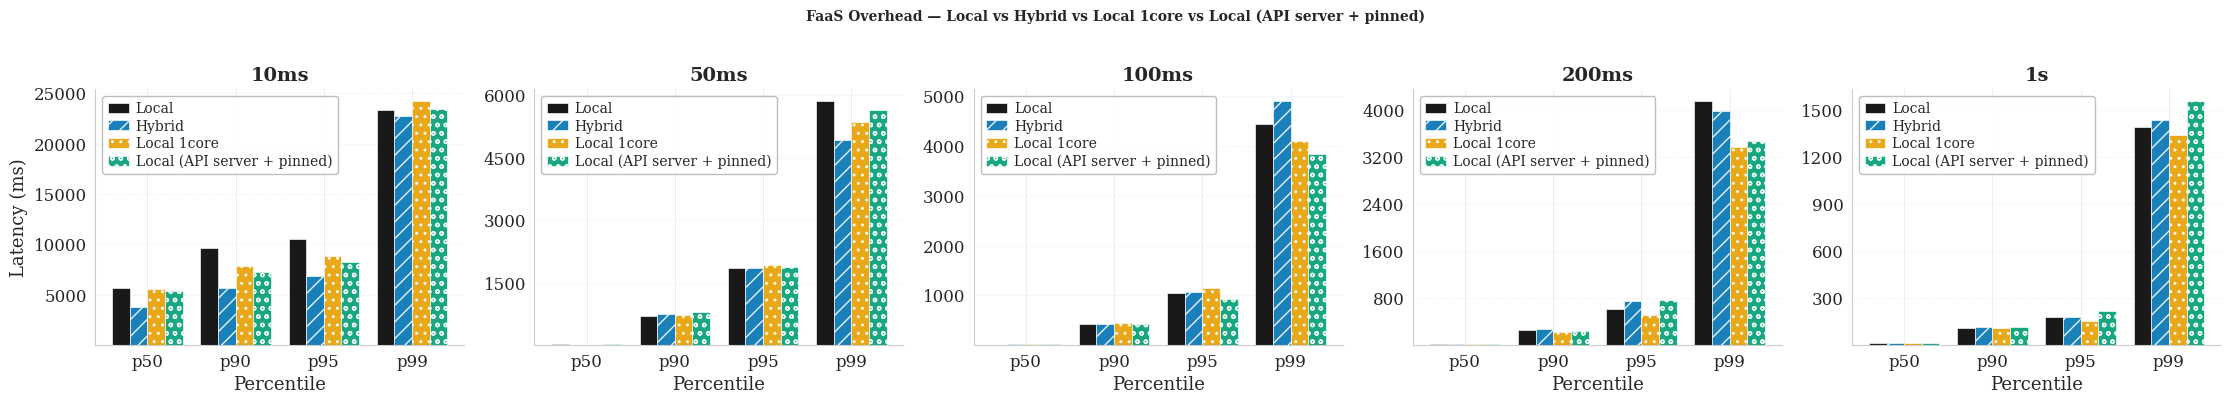

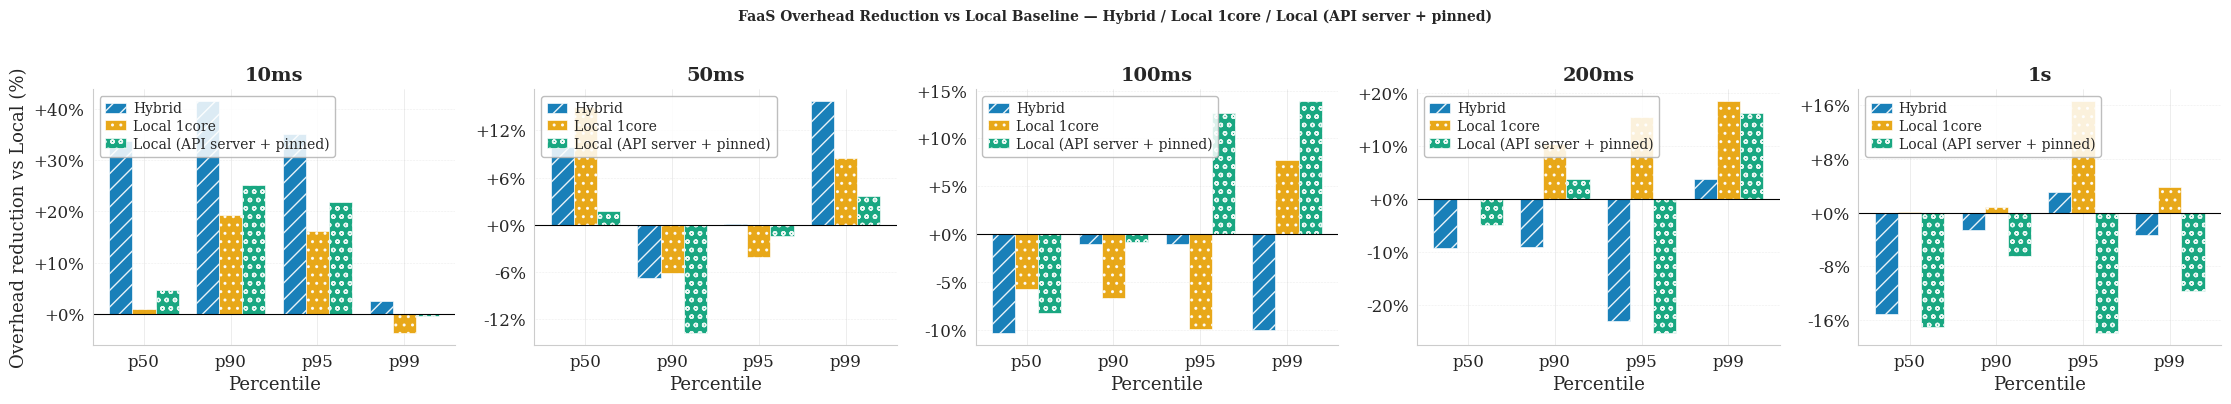

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os

# ─── STYLE ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          13,
    "axes.titlesize":     14,
    "axes.labelsize":     13,
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "legend.fontsize":    10,
    "legend.framealpha":  0.85,
    "legend.edgecolor":   "0.7",
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "grid.linewidth":     0.4,
    "grid.alpha":         0.5,
    "grid.color":         "0.75",
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

# ─── PALETTE ──────────────────────────────────────────────────────────
COLORS  = ["#0072B2", "#E69F00", "#009E73"]
HATCHES = ["//",      "..",      "oo"]
LABELS  = ["Hybrid", "Local 1core", "Local (API server + pinned)"]

# ─── CONFIG ───────────────────────────────────────────────────────────
DELAYS        = ["10ms", "50ms", "100ms", "200ms", "1s"]
PERCENTILES   = [50, 90, 95, 99]
PCTILE_LABELS = ["p50", "p90", "p95", "p99"]

DATA_DIR = "."

FILES = {
    "Local":           {d: os.path.join(DATA_DIR, f"all_data_{d}.csv")                  for d in DELAYS},
    "Hybrid":          {d: os.path.join(DATA_DIR, f"all_data_{d}_hybrid.csv")           for d in DELAYS},
    "Local1core":      {d: os.path.join(DATA_DIR, f"all_data_{d}_1core.csv")            for d in DELAYS},
    "APIserverPinned": {d: os.path.join(DATA_DIR, f"all_data_{d}_apiserver_pinned.csv") for d in DELAYS},
}

COMPARE_MODES = ["Hybrid", "Local1core", "APIserverPinned"]

# ─── CHARGEMENT ───────────────────────────────────────────────────────
def load_series(filepath):
    if not filepath or not os.path.exists(filepath):
        return None
    df = pd.read_csv(filepath)
    if "diff" not in df.columns:
        return None
    return df["diff"].dropna()

# ─── CHECK AVAILABLE FILES ────────────────────────────────────────────
available_delays = []
for d in DELAYS:
    local_ok = os.path.exists(FILES["Local"][d])
    has_any  = any(os.path.exists(FILES[m][d]) for m in COMPARE_MODES)
    if local_ok and has_any:
        available_delays.append(d)

print(f"Delays with data: {available_delays}")
if not available_delays:
    raise RuntimeError("Aucun fichier trouvé.")

# ─── FIGURE 1 : overhead absolu (ms) ──────────────────────────────────
n         = len(available_delays)
n_modes   = len(COMPARE_MODES) + 1   # Local + 3
n_pctiles = len(PERCENTILES)
x         = np.arange(n_pctiles)
bar_width = 0.8 / n_modes

fig1, axes1 = plt.subplots(1, n, figsize=(4.5 * n, 4), sharey=False)
if n == 1:
    axes1 = [axes1]

all_modes  = ["Local"] + COMPARE_MODES
all_colors = ["#000000"] + COLORS
all_hatch  = [""] + HATCHES
all_labels = ["Local"] + LABELS

for c, delay in enumerate(available_delays):
    ax = axes1[c]
    for i, mode in enumerate(all_modes):
        data = load_series(FILES[mode][delay])
        if data is None:
            continue
        vals   = [np.percentile(data, p) for p in PERCENTILES]
        offset = (i - n_modes / 2 + 0.5) * bar_width
        ax.bar(x + offset, vals, width=bar_width,
               color=all_colors[i], hatch=all_hatch[i],
               label=all_labels[i], edgecolor="white",
               linewidth=0.5, alpha=0.9)
        print(f"  [ABS] {all_labels[i]:35s} / {delay} p50={vals[0]:.1f} p99={vals[3]:.1f}")

    ax.set_title(delay, fontweight='bold')
    ax.set_xlabel("Percentile")
    ax.set_xticks(x)
    ax.set_xticklabels(PCTILE_LABELS)
    if c == 0:
        ax.set_ylabel("Latency (ms)")
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, prune='both'))
    ax.grid(True, axis='y', linestyle=':', linewidth=0.4, color='0.75')
    ax.tick_params(direction='out', length=3, width=0.6, pad=3)
    ax.legend(loc='upper left', handlelength=1.5, borderpad=0.4,
              labelspacing=0.25, handletextpad=0.5)

fig1.suptitle("FaaS Overhead — Local vs Hybrid vs Local 1core vs Local (API server + pinned)",
              fontsize=10, fontweight='bold', y=1.01)
plt.tight_layout()
fig1.savefig("overhead_abs.pdf", dpi=300, bbox_inches="tight")
fig1.savefig("overhead_abs.png", dpi=300, bbox_inches="tight")
print("\n✓ Saved: overhead_abs.pdf / .png")

# ─── FIGURE 2 : gain relatif vs Local (%) ─────────────────────────────
# Message OSDI : "combien de % de gain par rapport à Local ?"
# Valeur positive = amélioration, négative = dégradation

fig2, axes2 = plt.subplots(1, n, figsize=(4.5 * n, 4), sharey=False)
if n == 1:
    axes2 = [axes2]

for c, delay in enumerate(available_delays):
    ax = axes2[c]

    base_data = load_series(FILES["Local"][delay])
    if base_data is None:
        continue
    base_vals = np.array([np.percentile(base_data, p) for p in PERCENTILES])

    n_cmp     = len(COMPARE_MODES)
    bar_width2 = 0.8 / n_cmp

    for i, mode in enumerate(COMPARE_MODES):
        data = load_series(FILES[mode][delay])
        if data is None:
            continue
        vals   = np.array([np.percentile(data, p) for p in PERCENTILES])
        # gain % : positif = moins d'overhead que Local
        gains  = (base_vals - vals) / base_vals * 100
        offset = (i - n_cmp / 2 + 0.5) * bar_width2

        bars = ax.bar(x + offset, gains, width=bar_width2,
                      color=COLORS[i], hatch=HATCHES[i],
                      label=LABELS[i], edgecolor="white",
                      linewidth=0.5, alpha=0.9)

        print(f"  [REL] {LABELS[i]:35s} / {delay} "
              f"p50={gains[0]:+.1f}%  p99={gains[3]:+.1f}%")

    ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
    ax.set_title(delay, fontweight='bold')
    ax.set_xlabel("Percentile")
    ax.set_xticks(x)
    ax.set_xticklabels(PCTILE_LABELS)
    if c == 0:
        ax.set_ylabel("Overhead reduction vs Local (%)")
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6, prune='both'))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:+.0f}%"))
    ax.grid(True, axis='y', linestyle=':', linewidth=0.4, color='0.75')
    ax.tick_params(direction='out', length=3, width=0.6, pad=3)
    ax.legend(loc='upper left', handlelength=1.5, borderpad=0.4,
              labelspacing=0.25, handletextpad=0.5)

fig2.suptitle(
    "FaaS Overhead Reduction vs Local Baseline — Hybrid / Local 1core / Local (API server + pinned)",
    fontsize=10, fontweight='bold', y=1.01)
plt.tight_layout()
fig2.savefig("overhead_relative.pdf", dpi=300, bbox_inches="tight")
fig2.savefig("overhead_relative.png", dpi=300, bbox_inches="tight")
print("✓ Saved: overhead_relative.pdf / .png")

Delays with data: ['10ms', '50ms', '100ms', '200ms', '1s']
  [OK]   Local / 10ms — 19992 samples, median=57.1ms, p99=3166.3ms
  [OK]   Hybrid / 10ms — 19984 samples, median=51.7ms, p99=3082.6ms
  [OK]   Local 1core / 10ms — 19991 samples, median=53.5ms, p99=3059.9ms
  [OK]   Local / 50ms — 20008 samples, median=23.2ms, p99=2723.0ms
  [OK]   Hybrid / 50ms — 20009 samples, median=23.2ms, p99=2708.8ms
  [OK]   Local 1core / 50ms — 20008 samples, median=23.4ms, p99=2740.3ms
  [OK]   Local / 100ms — 20008 samples, median=22.9ms, p99=2700.6ms
  [OK]   Hybrid / 100ms — 20009 samples, median=23.3ms, p99=2709.6ms
  [OK]   Local 1core / 100ms — 20009 samples, median=23.1ms, p99=2703.4ms
  [OK]   Local / 200ms — 20010 samples, median=23.3ms, p99=2697.4ms
  [OK]   Hybrid / 200ms — 20010 samples, median=23.4ms, p99=2707.5ms
  [OK]   Local 1core / 200ms — 20010 samples, median=23.2ms, p99=2700.0ms
  [OK]   Local / 1s — 20000 samples, median=23.5ms, p99=2711.9ms
  [OK]   Hybrid / 1s — 20000 samples, 

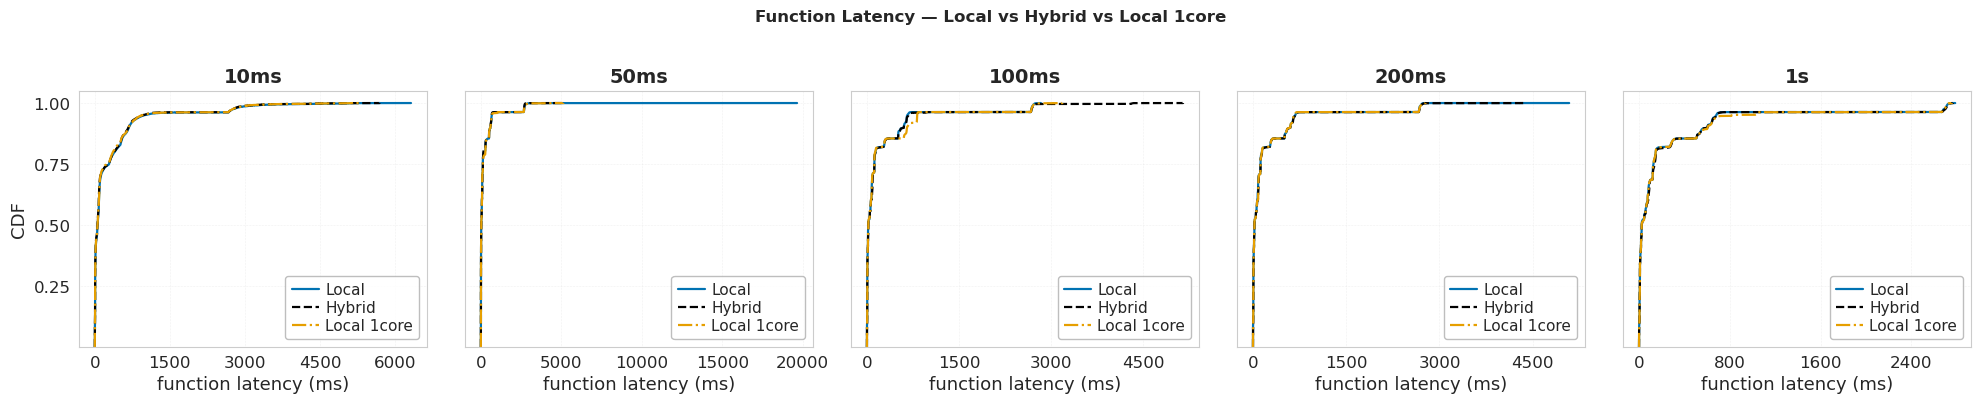

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import os

# ─── STYLE ────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          13,
    "axes.titlesize":     14,
    "axes.labelsize":     13,
    "xtick.labelsize":    12,
    "ytick.labelsize":    12,
    "legend.fontsize":    11,
    "legend.framealpha":  0.85,
    "legend.edgecolor":   "0.7",
    "axes.linewidth":     0.8,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "grid.linewidth":     0.4,
    "grid.alpha":         0.4,
    "grid.color":         "0.75",
    "lines.linewidth":    1.6,
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

sns.set_style("whitegrid")

# ─── PALETTE ──────────────────────────────────────────────────────────
COLORS     = ["#0072B2", "#000000",  "#E69F00"]   # noir, bleu, orange
LINESTYLES = ["-",       "--",      "-."]
LABELS     = ["Local", "Hybrid", "Local 1core"]

# ─── CONFIG ───────────────────────────────────────────────────────────
DELAYS = ["10ms", "50ms", "100ms", "200ms", "1s"]

DATA_DIR = "."

FILES = {
    "Local": {
        d: os.path.join(DATA_DIR, f"all_data_{d}.csv") for d in DELAYS
    },
    "Hybrid": {
        d: os.path.join(DATA_DIR, f"all_data_{d}_hybrid.csv") for d in DELAYS
    },
    "Local 1core": {
        d: os.path.join(DATA_DIR, f"all_data_{d}_1core.csv") for d in DELAYS
    },
}

MODES = ["Local", "Hybrid", "Local 1core"]

# ─── CHARGEMENT ───────────────────────────────────────────────────────
def load_series(filepath):
    if filepath is None or not os.path.exists(filepath):
        return None
    df = pd.read_csv(filepath)
    return df["execution_time_sec"].dropna()

# ─── STYLE AXES ───────────────────────────────────────────────────────
def style_ax(ax):
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5, prune='both'))
    ax.tick_params(direction='out', length=3, width=0.6, pad=3)
    ax.grid(True, linestyle=':', linewidth=0.4, color='0.75')

# ─── CHECK AVAILABLE FILES ────────────────────────────────────────────
available_delays = []
for d in DELAYS:
    has_any = any(os.path.exists(FILES[m][d]) for m in MODES)
    if has_any:
        available_delays.append(d)

print(f"Delays with data: {available_delays}")
if not available_delays:
    raise RuntimeError("Aucun fichier trouvé — vérifiez DATA_DIR et les noms de fichiers.")

# ─── FIGURE ───────────────────────────────────────────────────────────
n = len(available_delays)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

for c, delay in enumerate(available_delays):
    ax = axes[c]

    for i, mode in enumerate(MODES):
        filepath = FILES[mode][delay]
        data = load_series(filepath)
        if data is None:
            print(f"  [SKIP] {mode} / {delay} — file not found")
            continue

        print(f"  [OK]   {mode} / {delay} — {len(data)} samples, median={data.median():.1f}ms, p99={data.quantile(0.99):.1f}ms")

        sns.ecdfplot(
            data=data,
            ax=ax,
            color=COLORS[i],
            linestyle=LINESTYLES[i],
            linewidth=1.6,
            label=LABELS[i],
        )

    ax.set_title(delay, fontweight='bold')
    ax.set_xlabel("function latency (ms)")

    if c == 0:
        ax.set_ylabel("CDF")

    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:.2f}"))

    ax.legend(
        loc='lower right',
        handlelength=1.8,
        borderpad=0.4,
        labelspacing=0.2,
        handletextpad=0.4,
    )

    style_ax(ax)

# ─── TITRE ────────────────────────────────────────────────────────────
fig.suptitle(
    "Function Latency — Local vs Hybrid vs Local 1core",
    fontsize=12,
    fontweight='bold',
    y=1.01,
)

plt.tight_layout()

# ─── EXPORT ───────────────────────────────────────────────────────────
out_pdf = "func_ecdf_overlay.pdf"
out_png = "func_ecdf_overlay.png"

plt.savefig(out_pdf, dpi=300, bbox_inches="tight")
plt.savefig(out_png, dpi=300, bbox_inches="tight")

print(f"\n✓ Saved: {out_pdf}")
print(f"✓ Saved: {out_png}")